#CELL 1
# Module 2.2 — SHAP Explainability

This notebook explains the selected Logistic Regression attrition model using SHAP.

SHAP values quantify how much each transformed feature moved an individual employee's
predicted attrition risk above or below the model's baseline expectation.

In [2]:
#CELL 2
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import shap

# Ensure the project root is on Python's import path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.analytics.insights import (
    compute_shap_values,
    get_global_feature_importance,
    get_top_factors_for_employee,
)
from src.data.load import load_raw_ibm_hr
from src.data.preprocess import clean_hr_data
from src.modeling.attrition import (
    load_attrition_model,
    prepare_attrition_data,
    split_attrition_data,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

FIGURES_DIR = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: c:\Users\Anvesha Garg\Desktop\workforce360\workforce360
Figures directory: c:\Users\Anvesha Garg\Desktop\workforce360\workforce360\reports\figures


In [3]:
#CELL 3
raw_df = load_raw_ibm_hr()
clean_df = clean_hr_data(raw_df)

X, y = prepare_attrition_data(clean_df)
X_train, X_test, y_train, y_test = split_attrition_data(X, y)

model = load_attrition_model()

print(f"Training employees: {len(X_train):,}")
print(f"Test employees: {len(X_test):,}")
print(f"Attrition rate - test set: {y_test.mean():.1%}")

Training employees: 1,176
Test employees: 294
Attrition rate - test set: 16.0%


In [4]:
#CELL 4
shap_values, transformed_X = compute_shap_values(
    model=model,
    X_background=X_train.head(200),
    X_explain=X_test.head(200),
)

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"Transformed feature matrix shape: {transformed_X.shape}")

Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


SHAP values shape: (200, 48)
Transformed feature matrix shape: (200, 48)


In [5]:
#CELL 5
global_importance = get_global_feature_importance(
    shap_values=shap_values,
    top_n=20,
)

global_importance

,feature,mean_absolute_shap_value
0,numeric__job_level,0.503714
1,numeric__total_working_years,0.472964
2,numeric__years_since_promotion,0.436021
3,numeric__num_companies_worked,0.406886
4,numeric__years_with_curr_manager,0.389055
5,numeric__environment_satisfaction,0.365726
6,categorical__overtime_No,0.360755
7,numeric__job_satisfaction,0.328609
8,categorical__job_role_Laboratory Technician,0.318617
9,categorical__overtime_Yes,0.306624


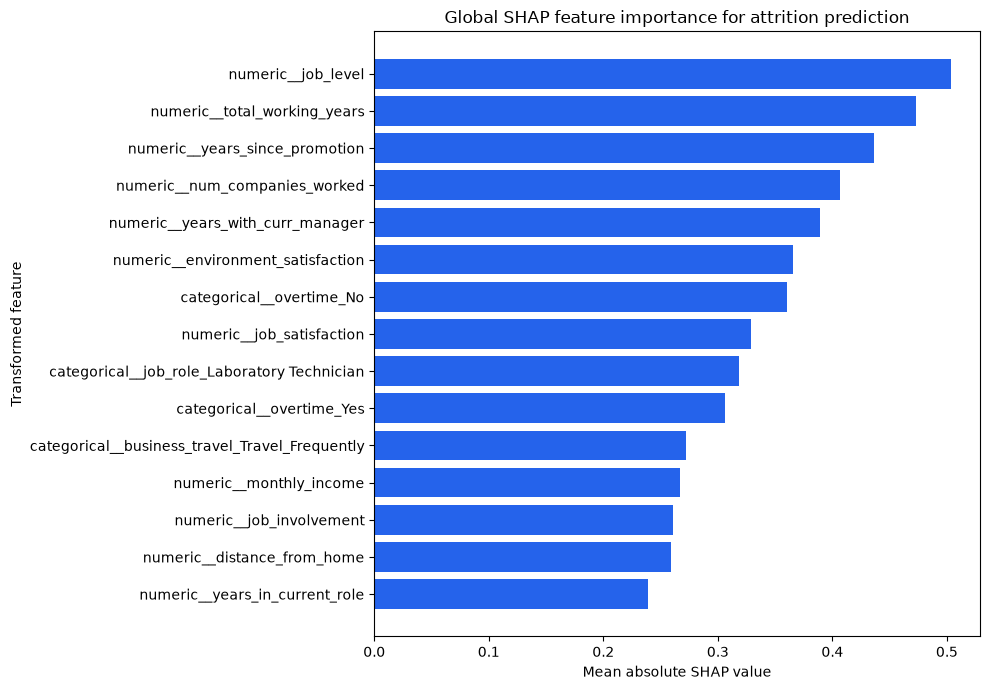

In [6]:
#CELL 6
fig, ax = plt.subplots(figsize=(10, 7))

top_features = global_importance.head(15).iloc[::-1]

ax.barh(
    top_features["feature"],
    top_features["mean_absolute_shap_value"],
    color="#2563eb",
)

ax.set_xlabel("Mean absolute SHAP value")
ax.set_ylabel("Transformed feature")
ax.set_title("Global SHAP feature importance for attrition prediction")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_global_importance.png", dpi=300, bbox_inches="tight")
plt.show()

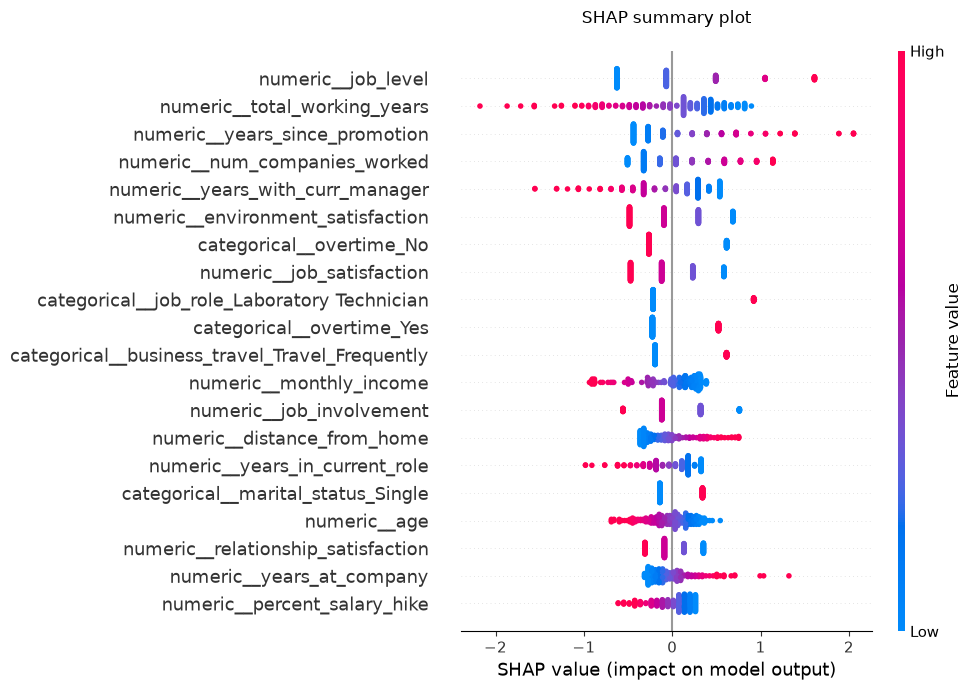

In [7]:
#CELL 7
shap.summary_plot(
    shap_values,
    transformed_X,
    max_display=20,
    show=False,
)

plt.gcf().set_size_inches(10, 7)
plt.title("SHAP summary plot", pad=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
#CELL 8
employee_position = 0

top_factors = get_top_factors_for_employee(
    shap_values=shap_values,
    transformed_features=transformed_X,
    employee_position=employee_position,
    top_n=10,
)

top_factors

,feature,feature_value,shap_value,impact_direction,absolute_impact
0,categorical__job_role_Sales Representative,1.000000,1.057325,increases_attrition_risk,1.057325
1,categorical__business_travel_Non-Travel,1.000000,-0.919841,decreases_attrition_risk,0.919841
2,numeric__total_working_years,-1.329148,0.819548,increases_attrition_risk,0.819548
3,numeric__job_level,-0.986265,-0.626009,decreases_attrition_risk,0.626009
4,numeric__years_with_curr_manager,-1.177687,0.537859,increases_attrition_risk,0.537859
5,numeric__environment_satisfaction,1.179114,-0.483475,decreases_attrition_risk,0.483475
6,numeric__years_since_promotion,-0.679165,-0.438245,decreases_attrition_risk,0.438245
7,numeric__age,-1.416826,0.363269,increases_attrition_risk,0.363269
8,numeric__years_in_current_role,-1.185905,0.326356,increases_attrition_risk,0.326356
9,numeric__num_companies_worked,-0.681293,-0.323274,decreases_attrition_risk,0.323274


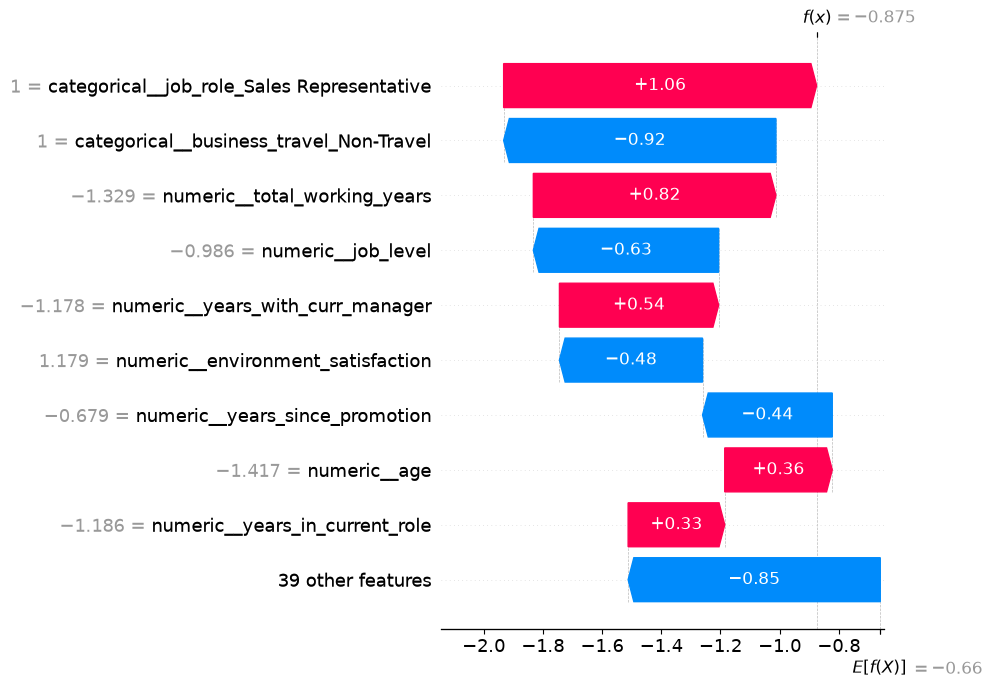

In [9]:
#CELL 9
shap.plots.waterfall(
    shap_values[employee_position],
    max_display=10,
    show=False,
)

plt.gcf().set_size_inches(10, 7)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "shap_employee_waterfall.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

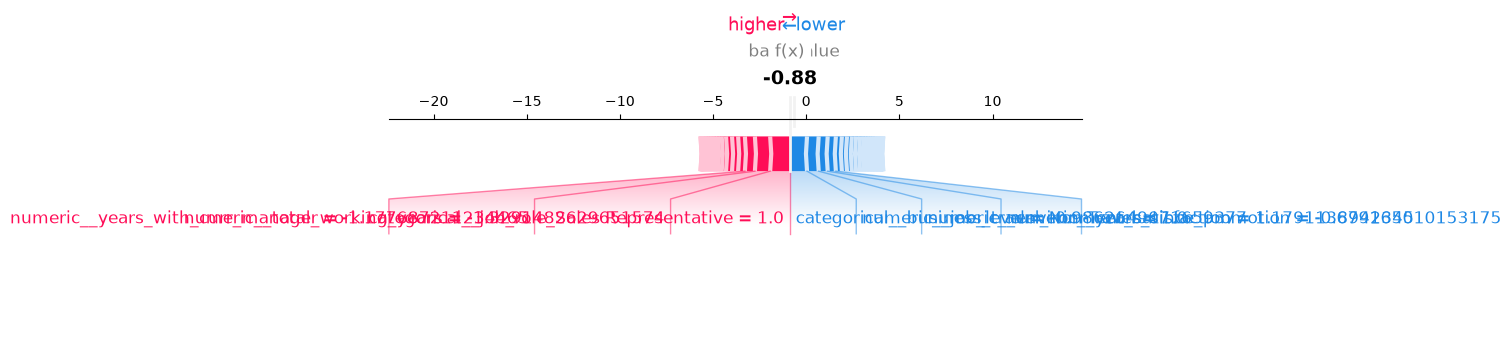

In [10]:
#CELL 10
shap.initjs()

shap.plots.force(
    shap_values[employee_position],
    matplotlib=True,
    show=False,
)

plt.gcf().set_size_inches(14, 4)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "shap_employee_force_plot.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

#CELL 11
## Interpretation

- Positive SHAP values increase the predicted probability of attrition.
- Negative SHAP values decrease the predicted probability of attrition.
- The global importance chart shows which transformed features have the largest average impact across the sample.
- The waterfall plot explains one employee's prediction by showing the features that pushed their risk above or below the model baseline.
- These explanations must be treated as model explanations, not proof of causation.

In [11]:
#CELL 12
global_importance.to_csv(
    ROOT / "reports" / "shap_global_feature_importance.csv",
    index=False,
)

top_factors.to_csv(
    ROOT / "reports" / "shap_employee_top_factors.csv",
    index=False,
)

print("Saved:")
print(ROOT / "reports" / "shap_global_feature_importance.csv")
print(ROOT / "reports" / "shap_employee_top_factors.csv")

Saved:
c:\Users\Anvesha Garg\Desktop\workforce360\workforce360\reports\shap_global_feature_importance.csv
c:\Users\Anvesha Garg\Desktop\workforce360\workforce360\reports\shap_employee_top_factors.csv
